# CycleGAN Inference Demo

Dieses Notebook nutzt das neue `src.apply_cyclegan`-Modul, um einen gespeicherten Generator auf Testbilder anzuwenden. Es wählt zufällig 5 Eingabebilder aus, wendet den Generator auf sie an und speichert die Ergebnisse unter `results/cyclegan_inference_demo/<direction>` (der Ordnernamen entspricht dem mapping). Eine Beispielkombination wird anschließend nebeneinander angezeigt.

## Ablauf
1. Konfiguration und Checkpoint laden.
2. Ausgewählte Testbilder aus `data/night2day/night_to_day/testA` bzw. `testB` einlesen.
3. Den passenden Generator (`G` für day→night, `F` für night→day) anwenden.
4. Ergebnisse abspeichern und eine Referenzseite nebeneinander visualisieren.

Wenn du `direction = "night2day"` setzt, verwenden wir automatisch `testB` als Input und `F` als Generator; die Ausgaben landen dann unter `results/cyclegan_inference_demo/night2day`.

In [1]:

from pathlib import Path
import random
import torch
from matplotlib import pyplot as plt
from PIL import Image
from torchvision import transforms
from typing import Optional

import os

os.chdir("/srv/store/docker-users/thesis/khajuria/day2night")
print("Current working directory:", os.getcwd())

from src.apply_cyclegan import (
    build_generator,
    build_inference_transform,
    gather_image_paths,
    find_checkpoint,
)
from src.utils.common import load_cfg

NUM_SAMPLES = 20  # Anzahl zufällig ausgewählter Bilder

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cfg = load_cfg("configs/cyclegan.yaml")


Current working directory: /srv/store/docker-users/thesis/khajuria/day2night


In [2]:

direction = True  # True für "day2night", False für "night2day"
mapping = "day2night" if direction else "night2day"
#input_dir = Path("data/bdd_split/cyclegan") / ("testA" if direction else "testB")
#input_dir = Path("data/cityscapes/leftImg8bit/test/berlin")
input_dir = Path("data/Straßen Bilder/test")
checkpoint = find_checkpoint(None, cfg)
print("Using checkpoint:", checkpoint)
extensions = cfg["data"].get("extensions", ("jpg", "jpeg", "png", "bmp", "tif", "tiff"))
image_paths = gather_image_paths(input_dir, extensions)
assert image_paths, "Keine Testbilder gefunden."
sample_paths = random.sample(image_paths, min(NUM_SAMPLES, len(image_paths)))
transform = build_inference_transform(cfg)
generator = build_generator(cfg, device, mapping)
state = torch.load(checkpoint, map_location="cpu", weights_only=True)
key = "G" if mapping == "day2night" else "F"
generator.load_state_dict(state[key])


Using checkpoint: experiments/cyclegan_day2night_20251218_235037/epoch_0200.pt
Building day2night generator | encoder: experiments/seg_20251204_174637/encoder_GE.pth | freeze=True


<All keys matched successfully>

In [3]:
#checkpoint = Path("experiments/cyclegan_day2night_20251212_012943/epoch_0200.pt")
print("Latest checkpoint:", checkpoint)

output_dir = Path("results/cyclegan_inference_demo") / checkpoint.parent.name / ("day2night" if direction else "night2day")
output_dir.mkdir(parents=True, exist_ok=True)


Latest checkpoint: experiments/cyclegan_day2night_20251218_235037/epoch_0200.pt


In [4]:

extensions = cfg["data"].get("extensions", ("jpg", "jpeg", "png", "bmp", "tif", "tiff"))
image_paths = gather_image_paths(input_dir, extensions)
assert image_paths, "Keine Testbilder gefunden."
sample_paths = random.sample(image_paths, min(NUM_SAMPLES, len(image_paths)))

resize_shorter = cfg["transforms"]["resize"]
crop_size = cfg["transforms"]["center_crop"]

transform = build_inference_transform(cfg)

generator = build_generator(cfg, device, mapping)
state = torch.load(checkpoint, map_location="cpu", weights_only=True)
key = "G" if mapping == "day2night" else "F"
generator.load_state_dict(state[key])
output_dir = Path("results/cyclegan_inference_demo") / checkpoint.parent.name / mapping
output_dir.mkdir(parents=True, exist_ok=True)

results_info = []
generator.eval()
to_pil = transforms.ToPILImage()
with torch.inference_mode():
    for image_path in sample_paths:
        img = Image.open(image_path).convert("RGB")
        orig_size = img.size
        input_tensor = transform(img).unsqueeze(0).to(device)
        input_hw = tuple(input_tensor.shape[-2:])
        output_tensor = generator(input_tensor).squeeze(0).cpu()
        output_tensor = output_tensor.mul(0.5).add(0.5).clamp(0.0, 1.0)
        result_img = to_pil(output_tensor)
        destination = output_dir / image_path.relative_to(input_dir)
        destination.parent.mkdir(parents=True, exist_ok=True)
        result_img.save(destination)
        results_info.append((image_path, destination, orig_size, input_hw, result_img.size))

print(f"Speicherort der generierten Bilder: {output_dir}")
print(
    f"Pipeline: Resize(kürzere Seite -> {resize_shorter}) -> CenterCrop({crop_size}) -> Normalize -> Generator -> Ausgabe gespeichert."
)


Building day2night generator | encoder: experiments/seg_20251204_174637/encoder_GE.pth | freeze=True
Speicherort der generierten Bilder: results/cyclegan_inference_demo/cyclegan_day2night_20251218_235037/day2night
Pipeline: Resize(kürzere Seite -> [512, 512]) -> CenterCrop(None) -> Normalize -> Generator -> Ausgabe gespeichert.


In [ ]:
#output_dir = Path("results/cyclegan_inference_demo") / ("day2night" if direction else "night2day")
#input_dir = Path("data/night2day/night_to_day") / ("testA" if direction else "testB" )  # Ursprüngliches Eingabeverzeichnis
print(f"Anzeigen von Beispielen aus: {output_dir}")
print(f"Eingabeverzeichnis: {input_dir}")
def show_samples(input_dir, output_dir):
    input_dir = Path(input_dir)
    output_dir = Path(output_dir)

    # all images in output_dir
    exts = {".jpg", ".jpeg", ".png", ".bmp"}
    output_files = sorted(
        p for p in output_dir.rglob("*") if p.suffix.lower() in exts
    )

    rows = max(1, len(output_files))
    fig, axes = plt.subplots(rows, 2, figsize=(12, 4 * rows))
    if rows == 1:
        axes = axes.reshape(1, 2)

    for row_idx, output_path in enumerate(output_files):
        # try to find matching input image by filename
        matches = list(input_dir.rglob(output_path.name))
        if not matches:
            print(f"No input found for {output_path.name}")
            continue
        input_path = matches[0]

        for col_idx, (path, title) in enumerate((
            (input_path, "Eingabe"),
            (output_path, "CycleGAN-Ausgabe"),
        )):
            ax = axes[row_idx, col_idx]
            ax.imshow(Image.open(path))
            ax.set_title(title)
            ax.axis("off")

    plt.tight_layout()


show_samples(input_dir, output_dir)


Anzeigen von Beispielen aus: results/cyclegan_inference_demo/cyclegan_day2night_20251218_235037/day2night
Eingabeverzeichnis: data/Straßen Bilder/test


In [ ]:
print('Größen: Original -> Crop -> gespeicherte Ausgabe')
for input_path, output_path, orig_size, crop_size, out_size in results_info:
    print(f"{input_path.name}: original={orig_size} crop={crop_size} out_saved={out_size}")



Größen: Original -> Crop -> gespeicherte Ausgabe
2018-06-18_19-59-23_657.jpg: original=(1920, 1080) crop=(512, 512) out_saved=(512, 512)
2018-06-18_19-59-59_866.jpg: original=(1920, 1080) crop=(512, 512) out_saved=(512, 512)
2018-06-18_20-00-25_493.jpg: original=(1920, 1080) crop=(512, 512) out_saved=(512, 512)
2018-06-18_19-01-49_013.jpg: original=(1920, 1080) crop=(512, 512) out_saved=(512, 512)
2018-06-25_09-43-40_853.jpg: original=(1920, 1080) crop=(512, 512) out_saved=(512, 512)


### Hinweise
- Die generierten Bilder stehen unter `results/cyclegan_inference_demo/day2night` oder `.../night2day`.
- Der verwendete Checkpoint ist `experiments/cyclegan_day2night_20251110_163433/epoch_0140.pt`.
- Du kannst `direction` ändern, um das night→day-Mapping zu nutzen; das Notebook wechselt dann automatisch zu `testB` und zum Generator `F`.
- Das `apply_generator`-Modul sichert die Eingaben/Ausgaben recht ähnlich zur CLI, sodass du dich auf den Ordner `results/cyclegan_inference_demo/<direction>` verlassen kannst.

In [ ]:

from src.models.cyclegan import PatchDiscriminator

mapping = "day2night" if direction else "night2day"
target_domain = "night" if direction else "day"

transform_cfg = cfg.get("transforms", {})
disc_cfg = cfg["model"]["discriminator"]
D_day = PatchDiscriminator(
    in_channels=disc_cfg.get("in_channels", 3),
    base_channels=disc_cfg.get("base_channels", 64),
    n_layers=disc_cfg.get("n_layers", 3),
    max_channels=disc_cfg.get("max_channels", 512),
    use_spectral_norm=disc_cfg.get("use_spectral_norm", False),
).to(device)
D_night = PatchDiscriminator(
    in_channels=disc_cfg.get("in_channels", 3),
    base_channels=disc_cfg.get("base_channels", 64),
    n_layers=disc_cfg.get("n_layers", 3),
    max_channels=disc_cfg.get("max_channels", 512),
    use_spectral_norm=disc_cfg.get("use_spectral_norm", False),
).to(device)
D_day.load_state_dict(state["D_day"])
D_night.load_state_dict(state["D_night"])
D_day.eval(); D_night.eval(); generator.eval()

print(
    f"Transformations-Pipeline für die Bewertung: resize={transform_cfg.get('resize')} -> center_crop={transform_cfg.get('center_crop')}"
)

def score_image(image_path: Path):
    img = Image.open(image_path).convert("RGB")
    inp = transform(img).unsqueeze(0).to(device)
    day_score = torch.sigmoid(D_day(inp)).mean().item()
    night_score = torch.sigmoid(D_night(inp)).mean().item()
    identity_l1 = torch.mean(torch.abs(generator(inp) - inp)).item()
    predicted = "day" if day_score >= night_score else "night"
    print(f"{image_path.name}: D_day={day_score:.4f}  D_night={night_score:.4f}  id_L1={identity_l1:.4f} -> {predicted} (target={target_domain})")
    return day_score, night_score, identity_l1

print("Diskriminator-Einschätzung (Input-Bild, vor der Umwandlung):")
for path in sample_paths:
    score_image(path)


Transformations-Pipeline für die Bewertung: resize=[512, 512] -> center_crop=None
Diskriminator-Einschätzung (Input-Bild, vor der Umwandlung):
2018-06-18_19-59-23_657.jpg: D_day=0.6375  D_night=0.6363  id_L1=0.3709 -> day (target=night)
2018-06-18_19-59-59_866.jpg: D_day=0.6101  D_night=0.6062  id_L1=0.3967 -> day (target=night)
2018-06-18_20-00-25_493.jpg: D_day=0.6143  D_night=0.6273  id_L1=0.3530 -> night (target=night)
2018-06-18_19-01-49_013.jpg: D_day=0.6503  D_night=0.6612  id_L1=0.6560 -> night (target=night)
2018-06-25_09-43-40_853.jpg: D_day=0.6312  D_night=0.6181  id_L1=1.0979 -> day (target=night)


# Strech

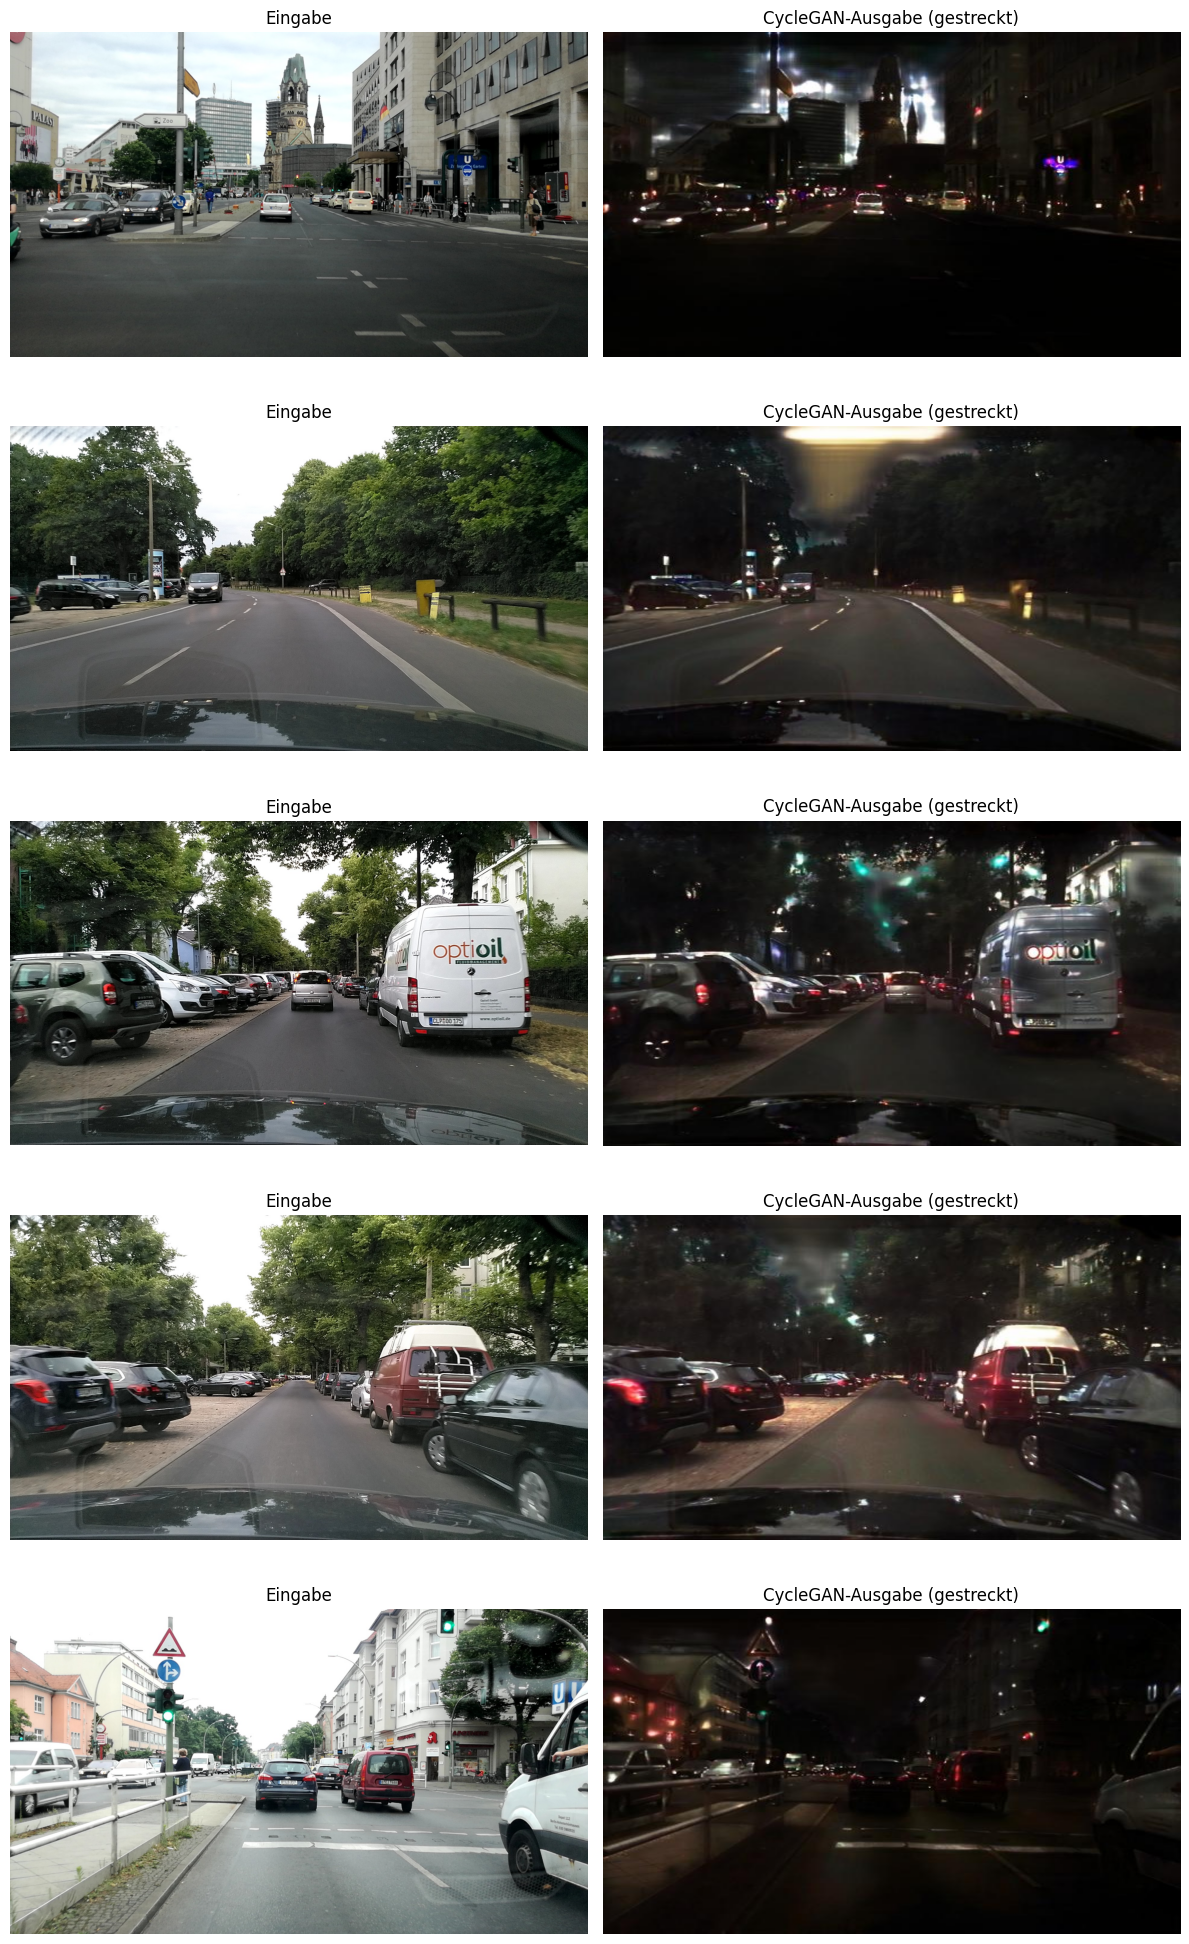

In [ ]:
def show_samples(input_dir, output_dir, stretch=False, target_ratio=(16, 9)):
    input_dir = Path(input_dir)
    output_dir = Path(output_dir)

    exts = {".jpg", ".jpeg", ".png", ".bmp"}
    output_files = sorted(p for p in output_dir.rglob("*") if p.suffix.lower() in exts)

    rows = max(1, len(output_files))
    fig, axes = plt.subplots(rows, 2, figsize=(12, 4 * rows))
    if rows == 1:
        axes = axes.reshape(1, 2)

    for row_idx, output_path in enumerate(output_files):
        matches = list(input_dir.rglob(output_path.name))
        if not matches:
            print(f"No input found for {output_path.name}")
            continue
        input_path = matches[0]

        for col_idx, (path, title) in enumerate((
            (input_path, "Eingabe"),
            (output_path, "CycleGAN-Ausgabe (gestreckt)" if stretch else "CycleGAN-Ausgabe"),
        )):
            img = Image.open(path)
            if stretch and col_idx == 1:
                h = img.height
                w = max(1, round(h * target_ratio[0] / target_ratio[1]))  # 16:9 by default
                img = img.resize((w, h), Image.BICUBIC)
            ax = axes[row_idx, col_idx]
            ax.imshow(img)
            ax.set_title(title)
            ax.axis("off")

    plt.tight_layout()

# Beispielaufruf:data/cityscapes/leftImg8bit/test/berlin
show_samples(input_dir, output_dir, stretch=True)